# 1D Burgers Equation DEMO code

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


C:\Users\thamm\AppData\Local\Temp\ipykernel_1228\2450097419.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


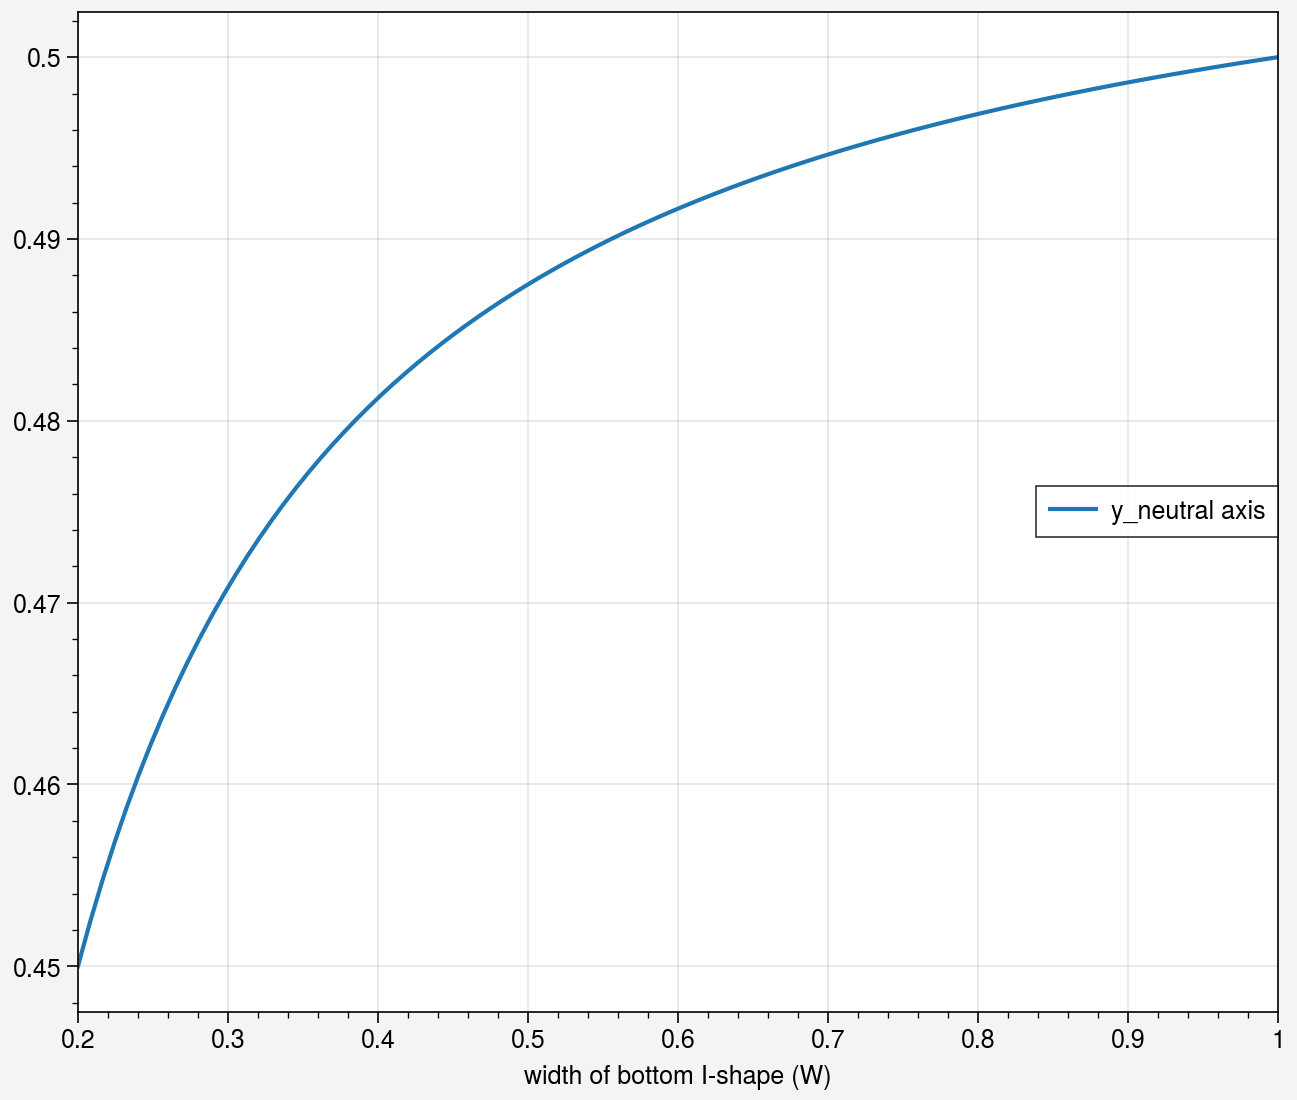

In [252]:
import numpy as np
import ultraplot as uplt
c = np.linspace(0.2,1,100)
L = 1
A = 0.05

w_1 = c
w_2 = 1
y_1 = L-A/(2*w_1)
y_2 = A/(2*w_2)
I_1_cm = 1/12*w_1*(A/w_1)**3
I_2_cm = 1/12*w_2*(A/w_2)**3
y_cm = (y_1+y_2)/2
I = I_1_cm + A*(y_1-y_cm)**2 + I_2_cm + A*(y_2-y_cm)**2

stress_tensile  = (y_cm)/I
stress_compressive = (L - y_cm)/I

fig, ax = uplt.subplot(refwidth = 6, aspect=1.2)
# ax.plot(c, I*18.5, label='(Scaled) I_neutral axis')
ax.plot(c, y_cm, label='y_neutral axis')
# ax.plot(c, stress_tensile*0.02, label='(Scaled) Max Tensile stress')
# ax.plot(c, stress_compressive*0.02, label='(Scaled) Max Compressive stress')
ax.xaxis.set_label_text('width of bottom I-shape (W)')
ax.legend()
fig.show()

C:\Users\thamm\AppData\Local\Temp\ipykernel_1228\345104290.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


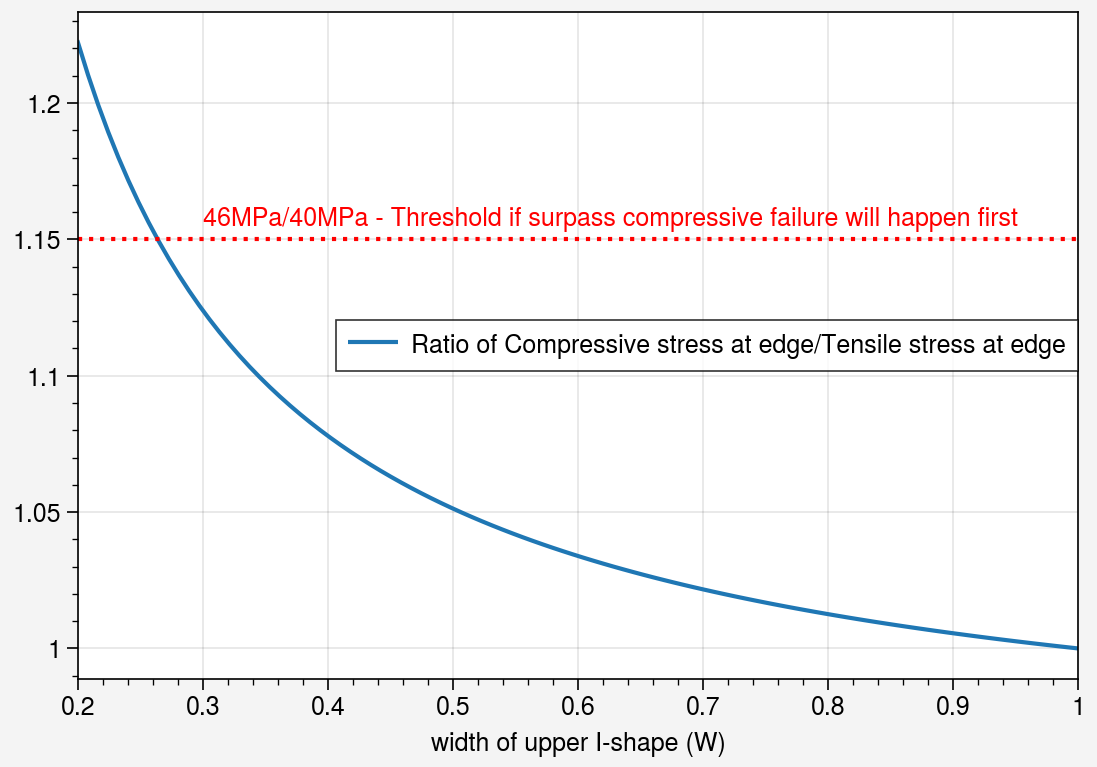

In [251]:

fig, ax = uplt.subplot(refwidth = 5, aspect=1.5)
# ax.plot(c, stress_tensile*0.02, label='(Scaled) Max Tensile stress')
# ax.plot(c, stress_compressive*0.02, label='(Scaled) Max Compressive stress')
ax.plot(c, stress_compressive/stress_tensile, label='Ratio of Compressive stress at edge/Tensile stress at edge')
ax.plot(c, 46/40*np.ones_like(c), linestyle=':', color='red')
ax.text(0.3, 46/40+0.005, "46MPa/40MPa - Threshold if surpass compressive failure will happen first", color='red')
ax.xaxis.set_label_text('width of upper I-shape (W)')
ax.legend()
fig.show()

C:\Users\thamm\AppData\Local\Temp\ipykernel_1228\2356331732.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


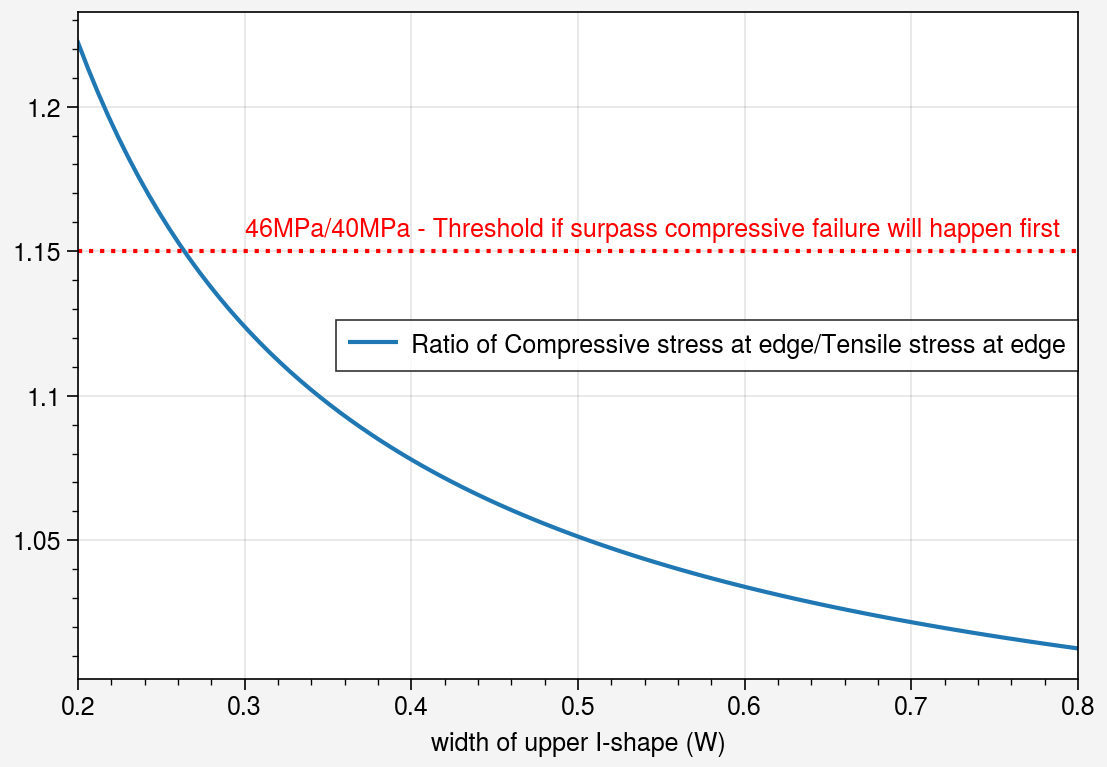

In [248]:
import numpy as np
import ultraplot as uplt
c = np.linspace(0.2,0.8,100)
L = 1
A = 0.05

w_1 = c
w_2 = 1
y_1 = L-A/(2*w_1)
y_2 = A/(2*w_2)
I_1_cm = 1/12*w_1*(A/w_1)**3
I_2_cm = 1/12*w_2*(A/w_2)**3
y_cm = (y_1+y_2)/2
I = I_1_cm + A*(y_1-y_cm)**2 + I_2_cm + A*(y_2-y_cm)**2

stress_tensile  = (y_cm)/I
stress_compressive = (L - y_cm)/I

fig, ax = uplt.subplot(refwidth = 5, aspect=1.5)
ax.plot(c, stress_compressive/stress_tensile, label='Ratio of Compressive stress at edge/Tensile stress at edge')
ax.plot(c, 46/40*np.ones_like(c), linestyle=':', color='red')
ax.text(0.3, 46/40+0.005, "46MPa/40MPa - Threshold if surpass compressive failure will happen first", color='red')
ax.xaxis.set_label_text('width of upper I-shape (W)')
ax.legend()
fig.show()

## 1. Define Geometry Domain
Set up the computational domain

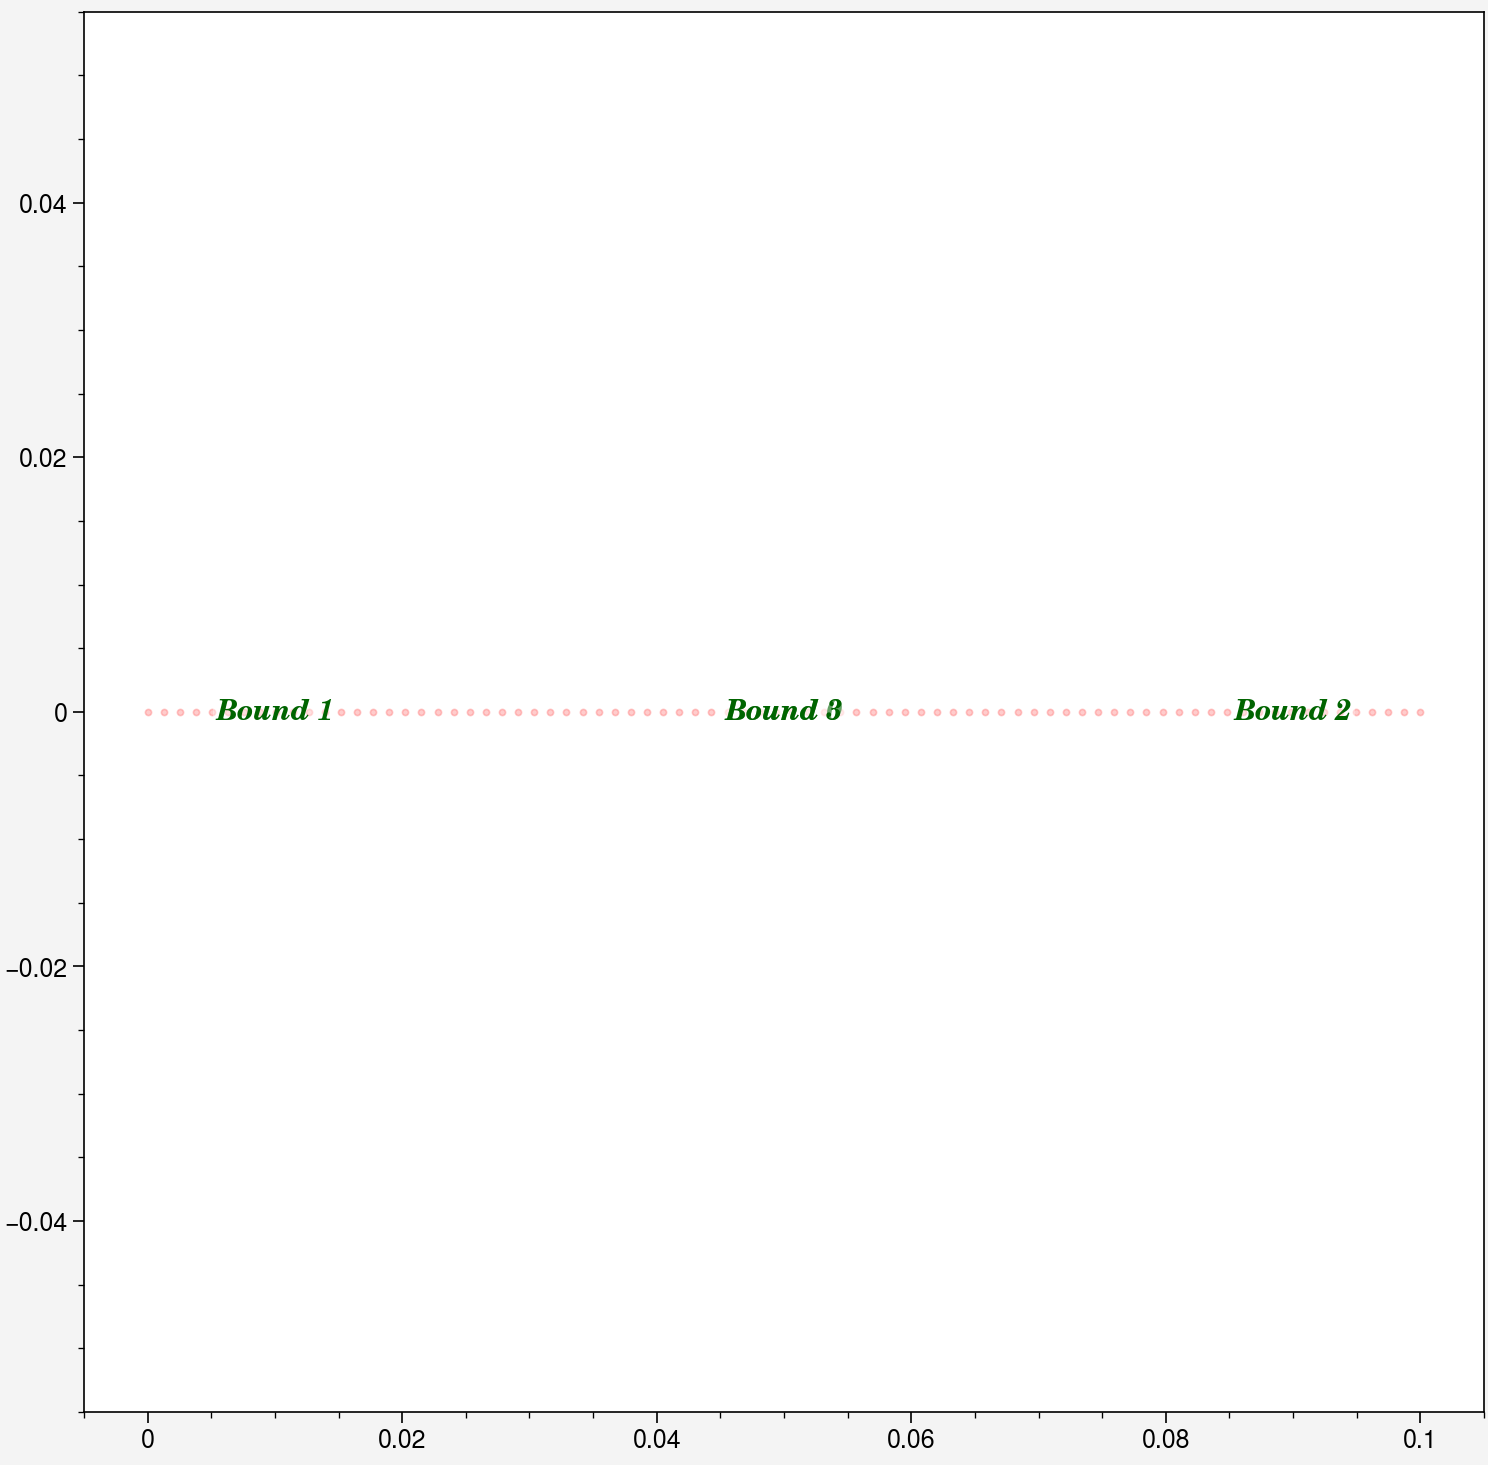

In [2]:
line_ic = df.geometry.line_horizontal(y=0, range_x=[0,0.1])
point1 = df.geometry.point(x=0.01, y=0)
point2 = df.geometry.point(x=0.09, y=0)
point3 = df.geometry.point(x=0.05, y=0)
domain = df.domain(line_ic, point1, point2, point3)
domain.show_setup()

In [3]:
import torch
class Beambending(df.PDE):
    def __init__(self, E=2.2*10**9, I=0.0000001, F=1000):
        super().__init__()
        self.E = E
        self.I = I
        self.F = F
    
    def M(self, x):
        mask = (x > 0.01)
        mask2 = (x < 0.09)
        return torch.where(mask, self.F/2*(x-0.01), torch.where(mask2, self.F/2*(0.09-x), x*0.0))

    def compute_residuals(self, inputs_dict):
        x = inputs_dict['x']
        y = inputs_dict['u']

        y_x = df.calc_grad(y, x)
        y_xx = df.calc_grad(y_x, x)
        self.residual_fields = ((y_xx - self.M(x))/(self.E*self.I),)


## 2. Define Physics
Define the Burgers eq (spatial version) apply boundary conditions.

In [4]:
# Define PDE
from torch import sin, pi
domain.bound_list[0].define_pde(Beambending())
domain.bound_list[1].define_bc({'u': 0})
domain.bound_list[2].define_bc({'u': 0})
domain.bound_list[3].define_bc({'u_x': 0})

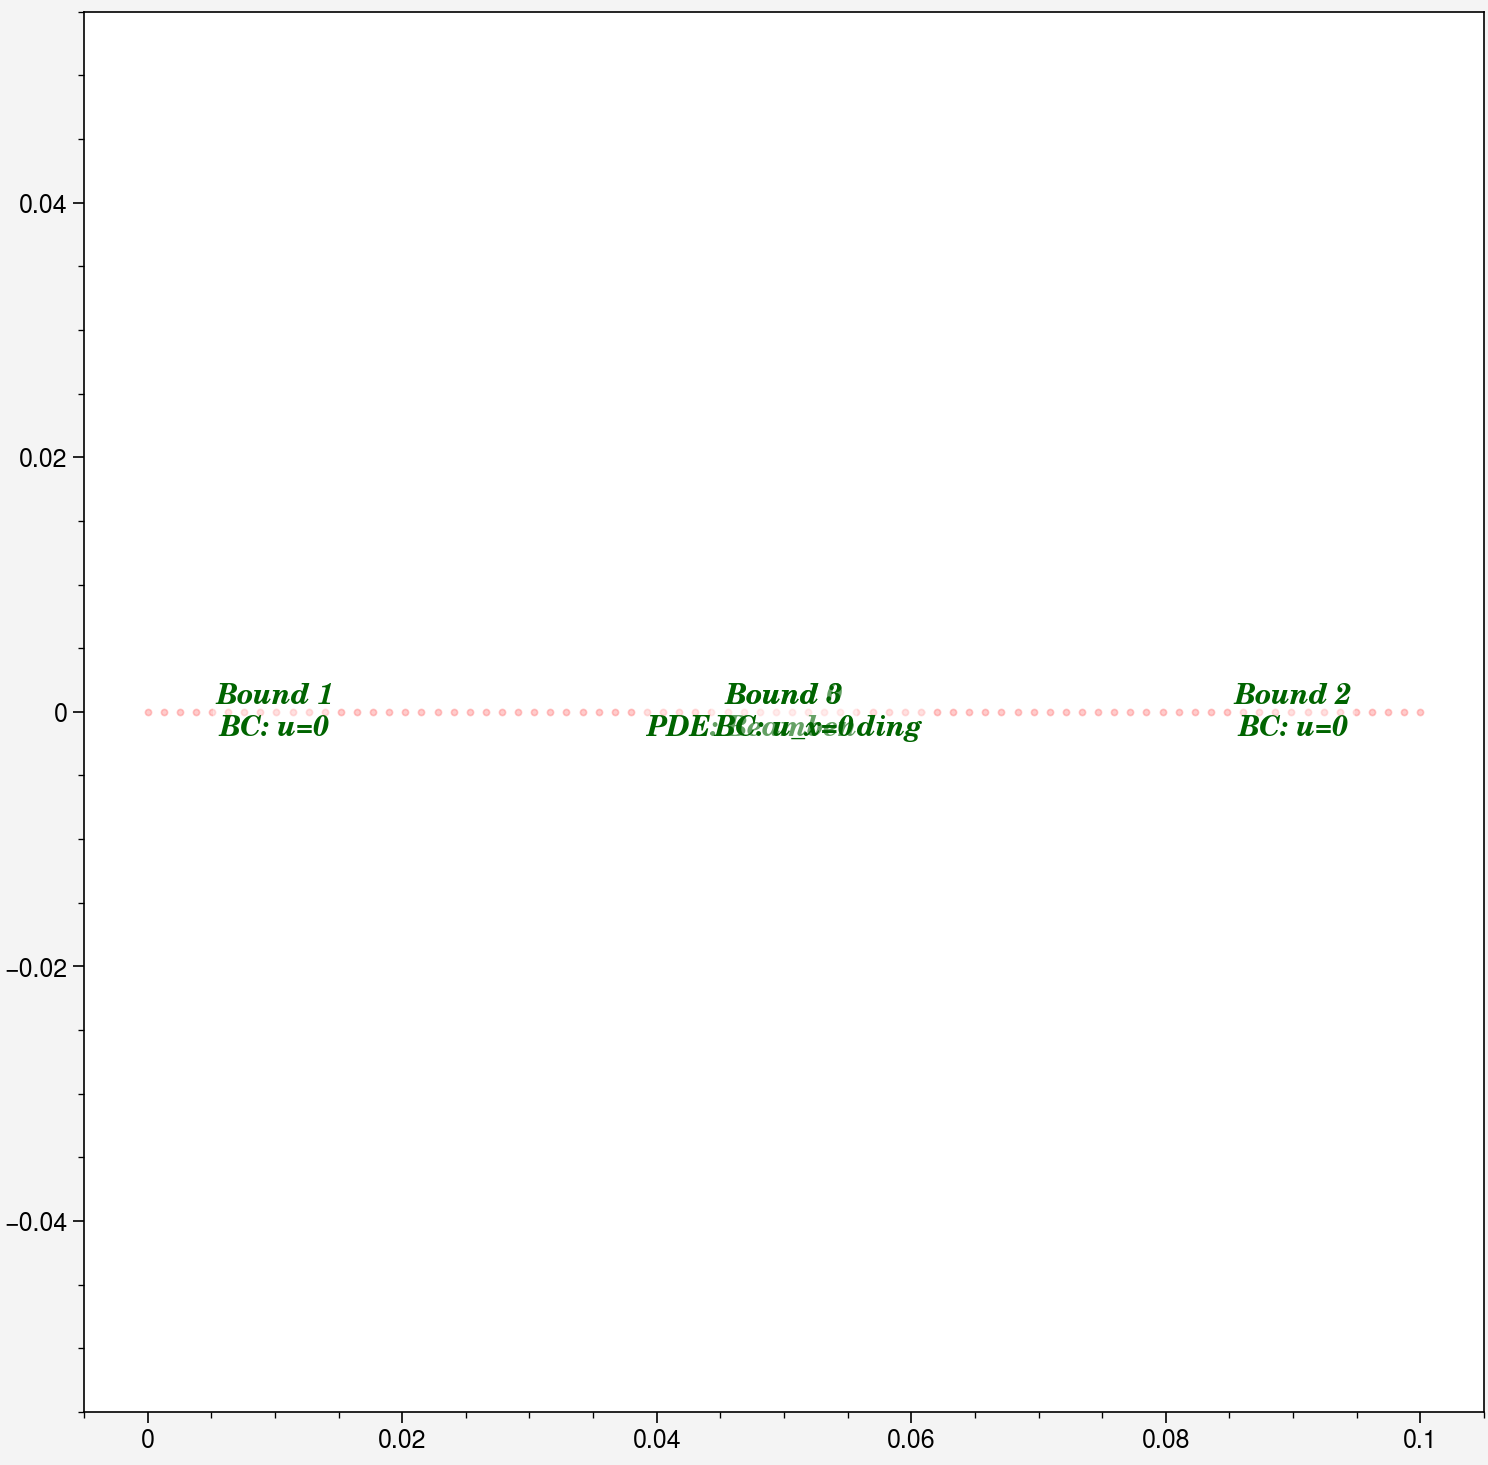

In [5]:
domain.show_setup()

### 2. Generate Training Data

Sample initial points for training. After sampling, Deepflow will automatically generate training datasets based on the defined physics.

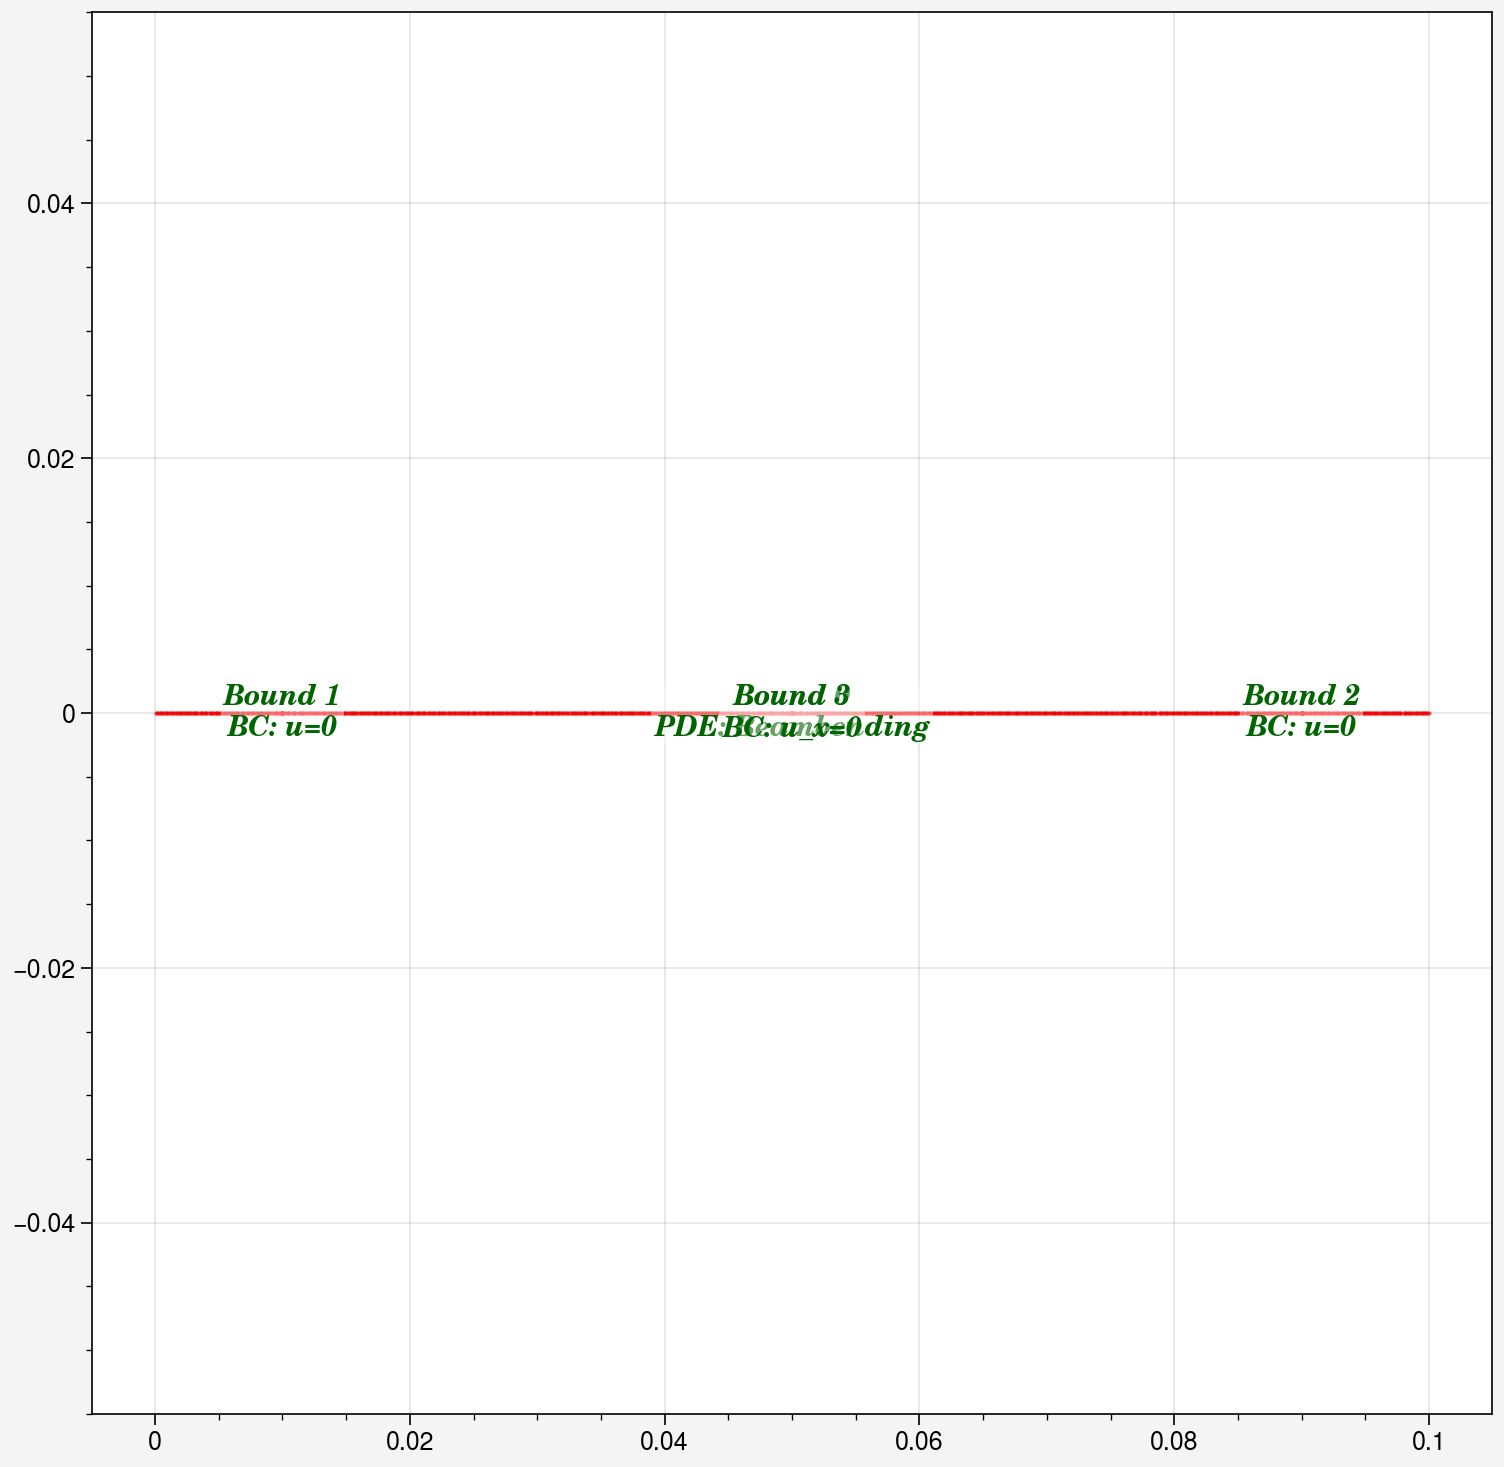

In [6]:
# Sample points: [Left, Bottom, Right, Top], [Interior]
domain.sampling_lhs([1000, 10, 10,10])
domain.show_coordinates(display_physics=True)

### 3. Train the Model

Define the resampling scheme during training. [R3](https://arxiv.org/abs/2207.02338) scheme is recommended.

Train the model using Adam optimizer followed by L-BFGS optimizer.

In [7]:
model0 = df.PINN(input_vars=['x'], output_vars=['u'], width=32, length=6)

model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_weighted(domain, bc_weights=1),
    learning_rate=0.001,
    epochs=2000)

Epoch: 1, total_loss: 0.01775, bc_loss: 0.00147, pde_loss: 0.01629
Epoch: 200, total_loss: 0.01400, bc_loss: 0.00013, pde_loss: 0.01387
Epoch: 400, total_loss: 0.00986, bc_loss: 0.00006, pde_loss: 0.00980
Epoch: 600, total_loss: 0.00562, bc_loss: 0.00000, pde_loss: 0.00562
Epoch: 800, total_loss: 0.00423, bc_loss: 0.00000, pde_loss: 0.00423
Epoch: 1000, total_loss: 0.00407, bc_loss: 0.00000, pde_loss: 0.00407
Epoch: 1200, total_loss: 0.01075, bc_loss: 0.00677, pde_loss: 0.00398
Epoch: 1400, total_loss: 0.00430, bc_loss: 0.00013, pde_loss: 0.00418
Epoch: 1600, total_loss: 0.00401, bc_loss: 0.00000, pde_loss: 0.00401
Epoch: 1800, total_loss: 0.00396, bc_loss: 0.00000, pde_loss: 0.00396
Epoch: 2000, total_loss: 0.00395, bc_loss: 0.00000, pde_loss: 0.00394
Epoch: 2000, total_loss: 0.00395, bc_loss: 0.00000, pde_loss: 0.00394


In [8]:
model2 = model1.train_lbfgs(
    calc_loss = df.calc_loss_weighted(domain, bc_weights=1),
    epochs=200)

Epoch: 2001, total_loss: 0.00374, bc_loss: 0.00000, pde_loss: 0.00374
Epoch: 2051, total_loss: 0.00265, bc_loss: 0.00002, pde_loss: 0.00263
Epoch: 2101, total_loss: 0.00265, bc_loss: 0.00002, pde_loss: 0.00263
Epoch: 2151, total_loss: 0.00265, bc_loss: 0.00002, pde_loss: 0.00263
Epoch: 2200, total_loss: 0.00265, bc_loss: 0.00002, pde_loss: 0.00263


## 4. Visualization

In [10]:
# Evaluate the best model
prediction = domain.bound_list[0].evaluate(model1)
prediction.sampling_line(n_points=100)


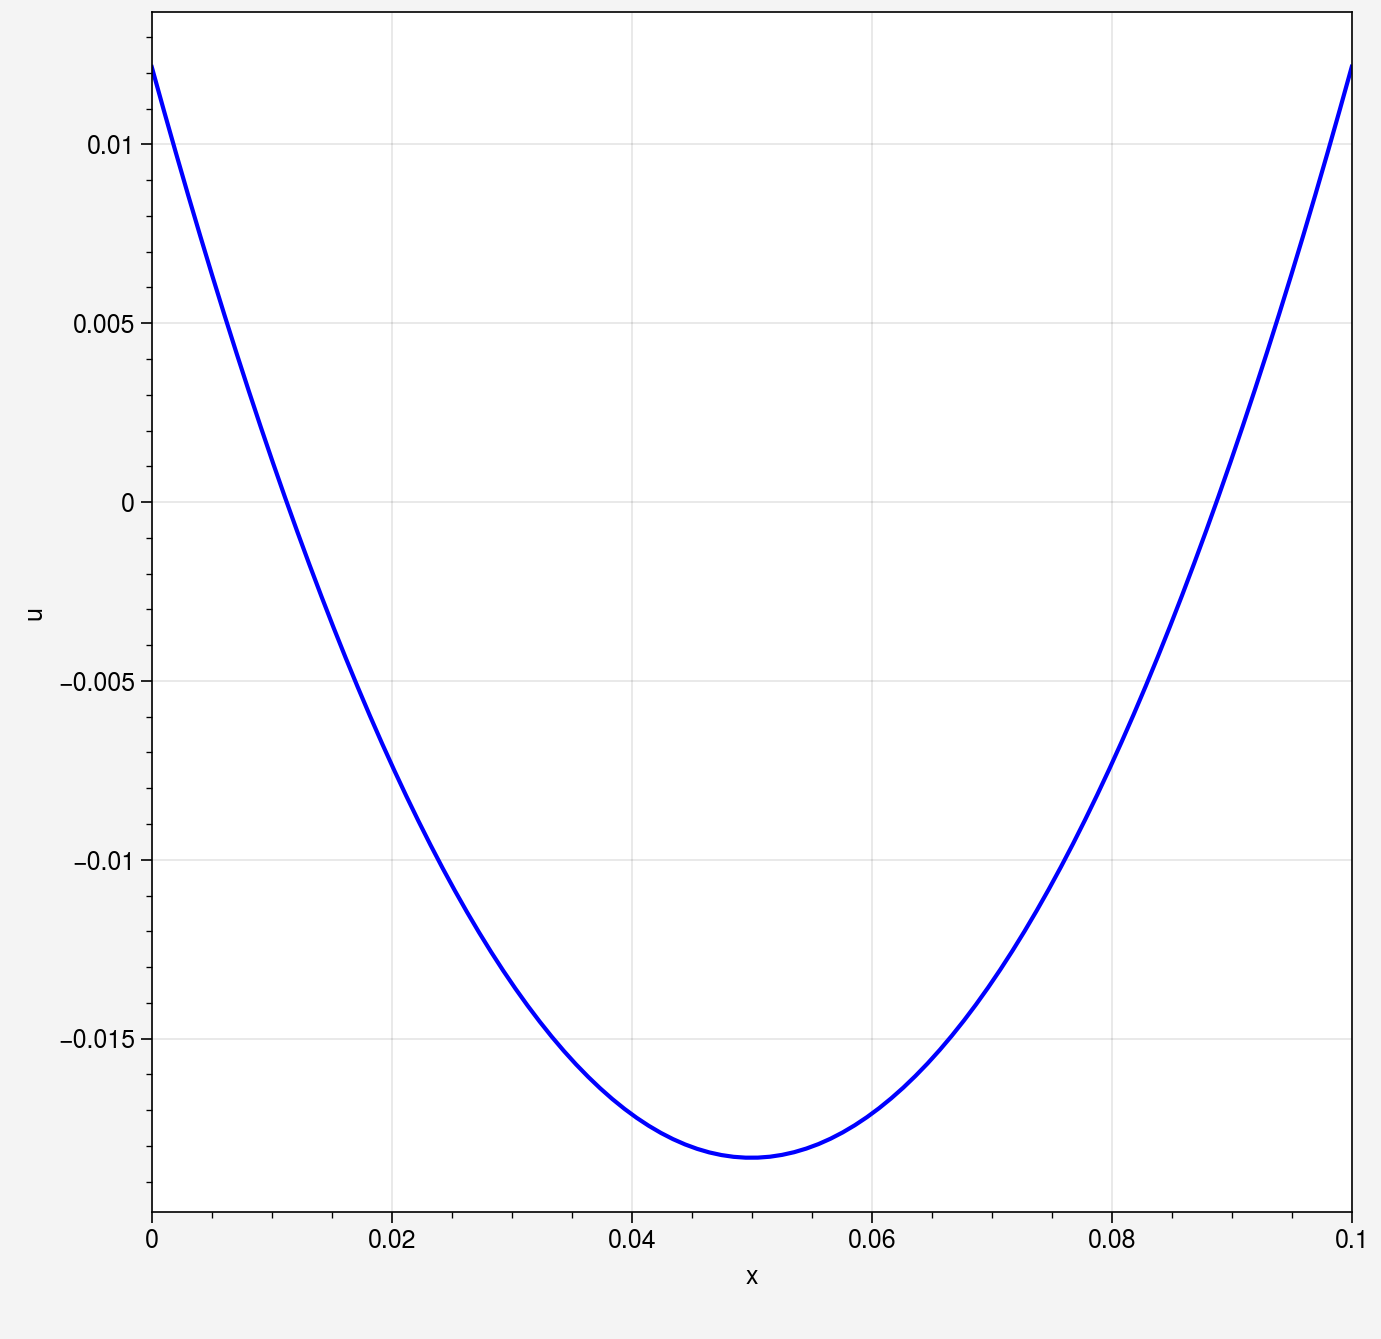

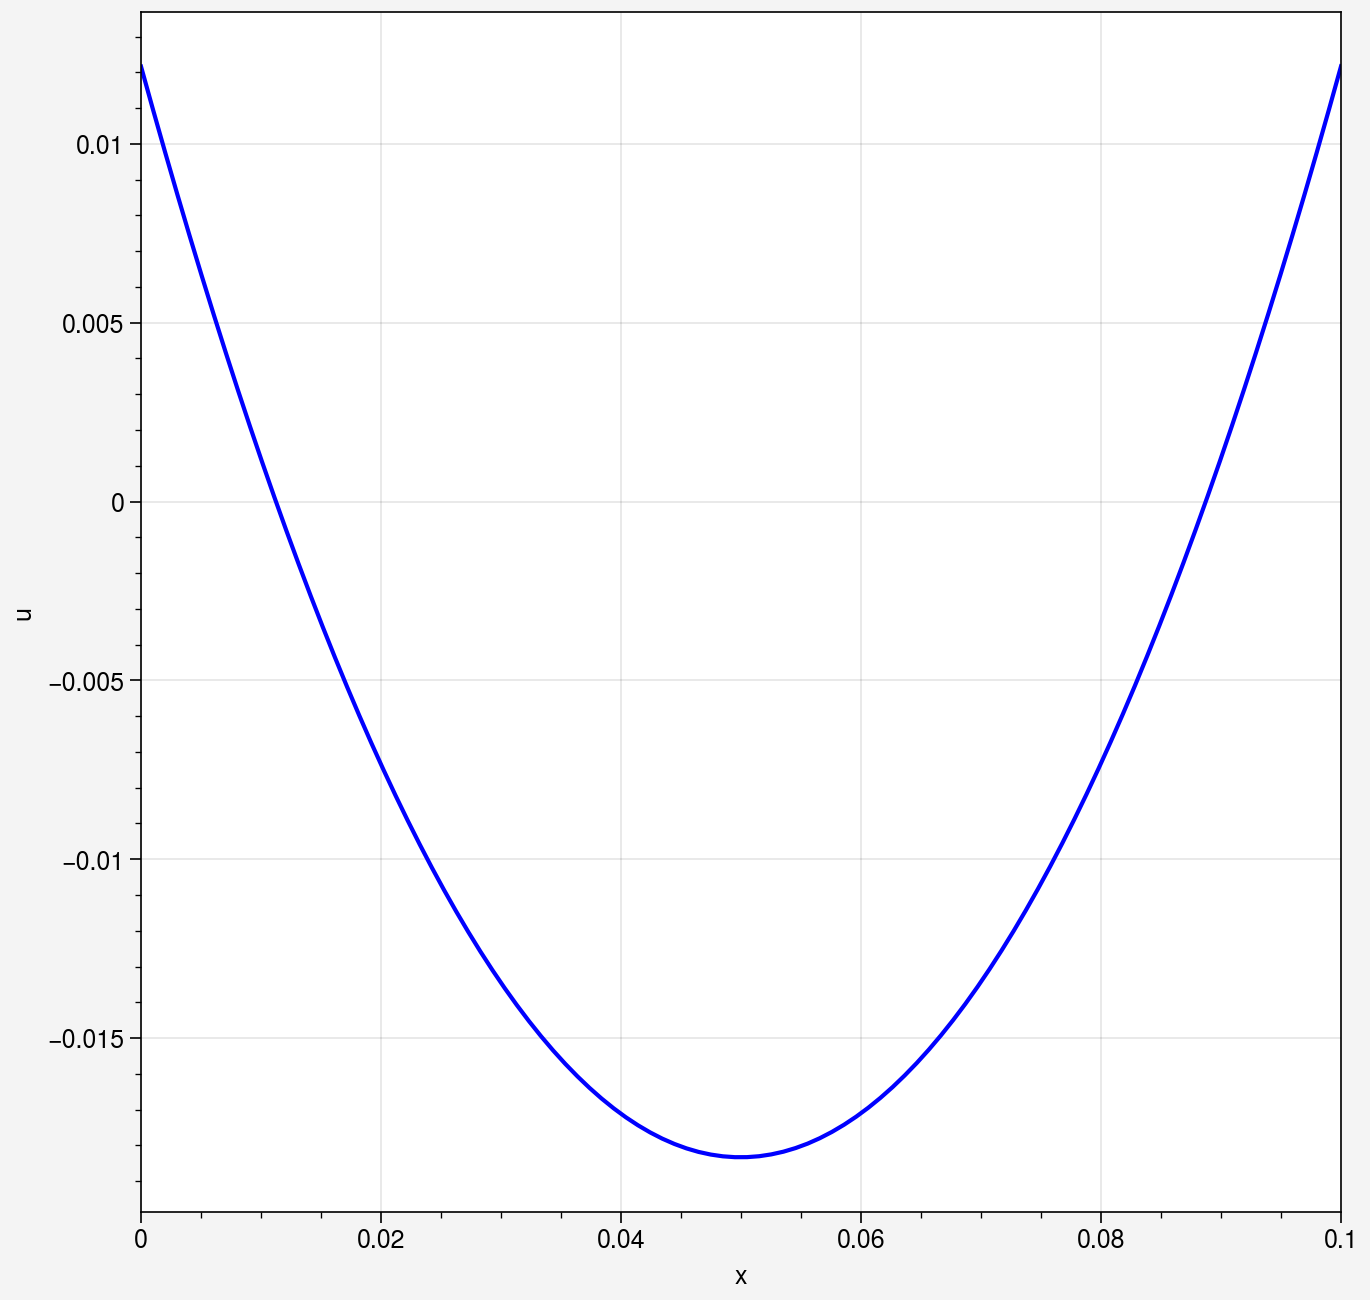

In [11]:
prediction.plot(y_axis='u')